In [1]:
import os

# נכוון את Spark להשתמש בגרסת פייתון של Conda
os.environ["PYSPARK_PYTHON"] = "/opt/conda/envs/bigdata/bin/python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/opt/conda/envs/bigdata/bin/python"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Analysis") \
    .getOrCreate()

# טוענים קובץ
df = spark.read.option("header", "true").option("inferSchema", "true").csv("hdfs://namenode:8020/user/mambauser/df_final_csv")
df.show(5)

+-------------+----------------------+------+-------+--------+--------------------+--------------+-----------------+-------------------+---+-----------+
|salary_decile|education_years_filled|salary|savings|zip_code|other_expenses_month|economic_class|work_sector_index|food_expenses_month|age|net_savings|
+-------------+----------------------+------+-------+--------+--------------------+--------------+-----------------+-------------------+---+-----------+
|            1|                  10.0|  2045|   3920|   17673|                1360|             1|              4.0|                468| 37|        217|
|            1|                  12.0|  2553|   4806|   29640|                1993|             1|              4.0|                413| 35|        147|
|            1|                  12.0|  2149|   3225|   27822|                1775|             1|              4.0|                504| 29|       -130|
|            1|                  13.0|  2130|   5133|   28227|                2151

In [2]:
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator


# 👩‍🏫 הנדסת פיצ'רים
df = df.withColumn("expense_ratio", (col("food_expenses_month") + col("other_expenses_month")) / col("salary"))
df = df.withColumn("disposable_income", col("net_savings") + col("savings"))
df = df.withColumn("salary_per_edu", col("salary") / (col("education_years_filled") + 1))

# 🎯 פילוח נתונים
df_labeled = df.filter(df["economic_class"].isNotNull())    # דאטה עם תוויות
df_unlabeled = df.filter(df["economic_class"].isNull())     # דאטה ללא תוויות

# 🧮 עמודות
numerical_cols = [
    "salary_decile", "salary", "savings", "net_savings",
    "food_expenses_month", "other_expenses_month",
    "expense_ratio", "disposable_income", "salary_per_edu"
]

categorical_cols = [
    "work_sector_index"
]

# 🏗️ שלבי Pipeline
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_indexed", handleInvalid="keep")
    for col in categorical_cols
]

all_features = numerical_cols + [f"{col}_indexed" for col in categorical_cols]

assembler = VectorAssembler(inputCols=all_features, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="economic_class",
    numTrees=100,
    maxDepth=6,
    seed=42
)

pipeline = Pipeline(stages=indexers + [assembler, scaler, rf])

# 🔀 Train/Test Split
train_data, test_data = df_labeled.randomSplit([0.8, 0.2], seed=42)

train_data = train_data.cache()  # ⬅️ הוספת cache כאן
train_data.count()  

# ✅ הערכת דיוק (יש להגדיר לפני CrossValidator)
evaluator = MulticlassClassificationEvaluator(
    labelCol="economic_class",
    predictionCol="prediction",
    metricName="accuracy"
)

# 🔧 טווחים לפרמטרים לבחינה
paramGrid = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [4, 6, 8]) \
    .addGrid(rf.numTrees, [50, 100]) \
    .build()

# 🔁 CrossValidator עם קיפול (3 folds)
crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

# 🧠 אימון עם כוונון פרמטרים
cv_model = crossval.fit(train_data)

# 🔮 תחזיות על הדאטה
predictions = cv_model.transform(test_data)

# 📊 דיוק המודל
accuracy = evaluator.evaluate(predictions)
print(f"\n🎯 דיוק המודל (Cross-Validated): {accuracy:.2f}")

# 📈 חשיבות הפיצ'רים מהמודל הטוב ביותר
rf_model = cv_model.bestModel.stages[-1]
importances = rf_model.featureImportances.toArray()

print("\n📌 חשיבות הפיצ'רים:")
for name, imp in zip(all_features, importances):
    print(f"{name}: {imp:.4f}")


🎯 דיוק המודל (Cross-Validated): 0.94

📌 חשיבות הפיצ'רים:
salary_decile: 0.1252
salary: 0.2197
savings: 0.0064
net_savings: 0.3576
food_expenses_month: 0.0656
other_expenses_month: 0.0495
expense_ratio: 0.1184
disposable_income: 0.0142
salary_per_edu: 0.0208
work_sector_index_indexed: 0.0226


In [3]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 🎯 Accuracy
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="economic_class",
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy = evaluator_accuracy.evaluate(predictions)

# ✅ Precision (ממוצע משוקלל)
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="economic_class",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
precision = evaluator_precision.evaluate(predictions)

# 🔍 Recall (ממוצע משוקלל)
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="economic_class",
    predictionCol="prediction",
    metricName="weightedRecall"
)
recall = evaluator_recall.evaluate(predictions)

# 📏 F1 Score
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="economic_class",
    predictionCol="prediction",
    metricName="f1"
)
f1 = evaluator_f1.evaluate(predictions)

# 📊 טבלת טעויות
confusion_matrix = predictions.groupBy("economic_class", "prediction").count()

# 🖨️ הדפסת התוצאות
print(f"\n📈 מדדים למודל:")
print(f"🎯 Accuracy: {accuracy:.2f}")
print(f"✅ Precision: {precision:.2f}")
print(f"🔍 Recall: {recall:.2f}")
print(f"📏 F1 Score: {f1:.2f}")

print("\n📊 Confusion Matrix:")
confusion_matrix.orderBy("economic_class", "prediction").show()


📈 מדדים למודל:
🎯 Accuracy: 0.94
✅ Precision: 0.94
🔍 Recall: 0.94
📏 F1 Score: 0.94

📊 Confusion Matrix:
+--------------+----------+-----+
|economic_class|prediction|count|
+--------------+----------+-----+
|             0|       0.0|   22|
|             0|       1.0|    2|
|             1|       0.0|    2|
|             1|       1.0|  102|
|             1|       2.0|    2|
|             2|       1.0|    4|
|             2|       2.0|  197|
|             2|       3.0|    3|
|             3|       2.0|    9|
|             3|       3.0|  155|
|             3|       4.0|    6|
|             4|       3.0|    2|
|             4|       4.0|  162|
|             4|       5.0|    5|
|             5|       4.0|    4|
|             5|       5.0|   92|
|             5|       6.0|    8|
|             6|       5.0|    4|
|             6|       6.0|  151|
|             6|       7.0|    6|
+--------------+----------+-----+
only showing top 20 rows



In [4]:
from pyspark.sql.functions import abs as abs_, avg, col, when, count

# חישוב מרחק מוחלט בין המחלקה האמיתית לבין התחזית
errors = predictions.withColumn(
    "abs_error",
    abs_(col("economic_class").cast("double") - col("prediction"))
)

# MAE על המחלקות – כמה רמות בממוצע אנחנו טועים
errors.select(avg("abs_error").alias("mean_abs_error")).show()

# פירוק: בול, טעות של 1, טעות של 2+
errors_dist = (
    errors
    .select(
        count(when(col("abs_error") == 0, True)).alias("exact"),
        count(when(col("abs_error") == 1, True)).alias("off_by_1"),
        count(when(col("abs_error") >= 2, True)).alias("off_by_2_plus")
    )
)

errors_dist.show()

+--------------------+
|      mean_abs_error|
+--------------------+
|0.062280701754385964|
+--------------------+

+-----+--------+-------------+
|exact|off_by_1|off_by_2_plus|
+-----+--------+-------------+
| 1069|      71|            0|
+-----+--------+-------------+



In [5]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# נזהה את כל המחלקות שקיימות בפועל
labels = [
    row["economic_class"]
    for row in predictions.select("economic_class").distinct().orderBy("economic_class").collect()
]

evaluator_pc = MulticlassClassificationEvaluator(
    labelCol="economic_class",
    predictionCol="prediction"
)

print("\n📊 Metrics per class:")
for lbl in labels:
    evaluator_pc.setMetricLabel(lbl)

    evaluator_pc.setMetricName("precisionByLabel")
    p = evaluator_pc.evaluate(predictions)

    evaluator_pc.setMetricName("recallByLabel")
    r = evaluator_pc.evaluate(predictions)

    evaluator_pc.setMetricName("fMeasureByLabel")
    f = evaluator_pc.evaluate(predictions)

    print(f"class {int(lbl)} → precision={p:.3f}, recall={r:.3f}, f1={f:.3f}")


📊 Metrics per class:
class 0 → precision=0.917, recall=0.917, f1=0.917
class 1 → precision=0.944, recall=0.962, f1=0.953
class 2 → precision=0.947, recall=0.966, f1=0.956
class 3 → precision=0.969, recall=0.912, f1=0.939
class 4 → precision=0.942, recall=0.959, f1=0.950
class 5 → precision=0.911, recall=0.885, f1=0.898
class 6 → precision=0.932, recall=0.938, f1=0.935
class 7 → precision=0.917, recall=0.966, f1=0.941
class 8 → precision=0.917, recall=0.863, f1=0.889
class 9 → precision=0.000, recall=0.000, f1=0.000


In [6]:
from pyspark.sql.functions import col, count

print("📊 כמה דוגמאות אמיתיות לכל מחלקה (label) ב-test:")
predictions.groupBy("economic_class") \
    .agg(count("*").alias("count")) \
    .orderBy("economic_class") \
    .show()

print("📊 כמה תחזיות לכל מחלקה (prediction):")
predictions.groupBy("prediction") \
    .agg(count("*").alias("count")) \
    .orderBy("prediction") \
    .show()

print("📊 רק השורות שבהן economic_class = 9:")
predictions.filter(col("economic_class") == 9) \
    .groupBy("economic_class", "prediction") \
    .agg(count("*").alias("count")) \
    .orderBy("prediction") \
    .show()

📊 כמה דוגמאות אמיתיות לכל מחלקה (label) ב-test:
+--------------+-----+
|economic_class|count|
+--------------+-----+
|             0|   24|
|             1|  106|
|             2|  204|
|             3|  170|
|             4|  169|
|             5|  104|
|             6|  161|
|             7|  149|
|             8|   51|
|             9|    2|
+--------------+-----+

📊 כמה תחזיות לכל מחלקה (prediction):
+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|   24|
|       1.0|  108|
|       2.0|  208|
|       3.0|  160|
|       4.0|  172|
|       5.0|  101|
|       6.0|  162|
|       7.0|  157|
|       8.0|   48|
+----------+-----+

📊 רק השורות שבהן economic_class = 9:
+--------------+----------+-----+
|economic_class|prediction|count|
+--------------+----------+-----+
|             9|       8.0|    2|
+--------------+----------+-----+



In [7]:
from pyspark.sql.functions import col

# 🧩 חיזוי על השורות החסרות (df_unlabeled)
predicted_unlabeled = cv_model.transform(df_unlabeled)

# 🧱 מילוי עמודת economic_class על סמך התחזית
df_filled_unlabeled = predicted_unlabeled.withColumn(
    "economic_class",
    col("prediction").cast("int")
)

# 🔗 איחוד כל הדאטה בחזרה
df_complete = df_labeled.unionByName(df_filled_unlabeled.select(df_labeled.columns))

# 💾 קאש – נשתמש בזה הרבה עכשיו
df_complete = df_complete.cache()
df_complete.count()
# ✔️ הצצה
df_complete.show(5)

# 🧪 בדיקה שאין חוסרים
print("Missing economic_class values:", df_complete.filter(col("economic_class").isNull()).count())

+-------------+----------------------+------+-------+--------+--------------------+--------------+-----------------+-------------------+---+-----------+------------------+-----------------+------------------+
|salary_decile|education_years_filled|salary|savings|zip_code|other_expenses_month|economic_class|work_sector_index|food_expenses_month|age|net_savings|     expense_ratio|disposable_income|    salary_per_edu|
+-------------+----------------------+------+-------+--------+--------------------+--------------+-----------------+-------------------+---+-----------+------------------+-----------------+------------------+
|            1|                  10.0|  2045|   3920|   17673|                1360|             1|              4.0|                468| 37|        217|0.8938875305623472|             4137| 185.9090909090909|
|            1|                  12.0|  2553|   4806|   29640|                1993|             1|              4.0|                413| 35|        147|0.9424206815

K=2, WSSSE=26854.99
K=3, WSSSE=19944.79
K=4, WSSSE=14495.03
K=5, WSSSE=12434.95
K=6, WSSSE=11223.85
K=7, WSSSE=10652.12
K=8, WSSSE=9306.30
K=9, WSSSE=8735.76
K=10, WSSSE=8336.92


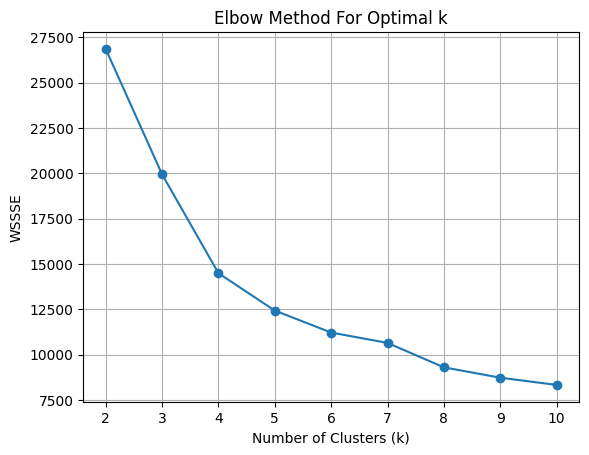

In [8]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

# 🧱 בחירת עמודות
features_cols = [
    "salary", "savings", "food_expenses_month",
    "expense_ratio", "disposable_income", "salary_per_edu",
    "education_years_filled", "work_sector_index"
]

# ⚙️ איחוד לעמודת features
assembler = VectorAssembler(inputCols=features_cols, outputCol="assembled_features")
assembled_df = assembler.transform(df_complete)

# 🔁 סקלינג
scaler = StandardScaler(inputCol="assembled_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

# 🧪 Elbow Method
cost = []
ks = list(range(2, 11))  # נבחן בין 2 ל-10 אשכולות

for k in ks:
    kmeans = KMeans(featuresCol="features", k=k, seed=42)
    model = kmeans.fit(scaled_df)
    wssse = model.summary.trainingCost
    cost.append(wssse)
    print(f"K={k}, WSSSE={wssse:.2f}")

# גרף Elbow (אם תריץ מתוך Jupyter או סביבת שתומכת גרפיקה)
plt.plot(ks, cost, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSSSE')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [9]:
from pyspark.ml.stat import Summarizer
from pyspark.ml.linalg import Vectors
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

# Step 1: ממוצע כולל של הפיצ'רים
mean_vector = scaled_df.select("features").rdd.map(lambda row: row[0]).mean()

# Step 2: חישוב TSS: סכום הריבועים של כל המרחקים לממוצע
def squared_distance(v1, v2):
    return float(v1.squared_distance(v2))

squared_distance_udf = udf(lambda v: squared_distance(v, mean_vector), DoubleType())
tss_df = scaled_df.withColumn("squared_distance", squared_distance_udf("features"))
TSS = tss_df.agg({"squared_distance": "sum"}).collect()[0][0]

# Step 3: חשב R² מדומה
WSS = model.summary.trainingCost  # מה-KMeans
r2_pseudo = 1 - (WSS / TSS)
print(f"Pseudo R² (Explained Variance): {r2_pseudo:.4f}")

Pseudo R² (Explained Variance): 0.8259


In [10]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(featuresCol="features", k=4, seed=42)
model = kmeans.fit(scaled_df)
kmeans_df = model.transform(scaled_df)  # מוסיף עמודת 'prediction'
# לצורך ניתוח קל יותר – נשלב את הפיצ'רים המקוריים בחזרה עם הקלאסטר
final_df = kmeans_df.select("prediction", *features_cols, "economic_class")

# ממוצעים לפי קלאסטר
final_df.groupBy("prediction").mean().show(truncate=False)
final_df.groupBy("prediction", "economic_class").count().orderBy("prediction", "economic_class").show()

+----------+---------------+------------------+-----------------+------------------------+-------------------+----------------------+-------------------+---------------------------+----------------------+-------------------+
|prediction|avg(prediction)|avg(salary)       |avg(savings)     |avg(food_expenses_month)|avg(expense_ratio) |avg(disposable_income)|avg(salary_per_edu)|avg(education_years_filled)|avg(work_sector_index)|avg(economic_class)|
+----------+---------------+------------------+-----------------+------------------------+-------------------+----------------------+-------------------+---------------------------+----------------------+-------------------+
|1         |1.0            |8074.412004069176 |53875.53509664293|1708.8463886063073      |0.42607341440011626|58539.81383519837     |421.43940247146975 |18.39674465920651          |2.953204476093591     |6.874872838250254  |
|3         |3.0            |3526.0243722304285|7247.882570162482|805.3833087149187       |0.72316481

In [11]:
from pyspark.ml.clustering import KMeans

# שלב 1: KMeans
kmeans = KMeans(featuresCol="features", k=4, seed=42)
model = kmeans.fit(scaled_df)
kmeans_df = model.transform(scaled_df)

# שלב 2: שלב פיצ'רים עם תחזית הקלאסטר
final_df = kmeans_df.select("prediction", *features_cols, "economic_class", "work_sector_index")

# שלב 3: ניתוח ממוצעים (תמשיך אם אתה רוצה ניתוח מספרי)
final_df.groupBy("prediction").mean().show(truncate=False)

# ❌ לא להציג ממוצעים למשתנים קטגוריאליים:
# final_df.groupBy("prediction", "economic_class").count().orderBy("prediction", "economic_class").show()

# ✅ במקום זאת – הוסף את קוד ההתפלגויות:

from pyspark.sql.functions import col, round

# חישוב גודל כל קלאסטר
cluster_sizes = final_df.groupBy("prediction").count().withColumnRenamed("count", "total_count")

# התפלגות work_sector_index לפי קלאסטר
sector_distribution = (
    final_df.groupBy("prediction", "work_sector_index")
    .count()
    .join(cluster_sizes, on="prediction")
    .withColumn("percentage", round((col("count") / col("total_count")) * 100, 1))
    .orderBy("prediction", "percentage", ascending=False)
)

print("🔹 התפלגות work_sector_index לפי קלאסטר:")
sector_distribution.show(100, truncate=False)

# התפלגות economic_class לפי קלאסטר
econ_distribution = (
    final_df.groupBy("prediction", "economic_class")
    .count()
    .join(cluster_sizes, on="prediction")
    .withColumn("percentage", round((col("count") / col("total_count")) * 100, 1))
    .orderBy("prediction", "percentage", ascending=False)
)

print("🔸 התפלגות economic_class לפי קלאסטר:")
econ_distribution.show(100, truncate=False)

+----------+---------------+------------------+-----------------+------------------------+-------------------+----------------------+-------------------+---------------------------+----------------------+-------------------+----------------------+
|prediction|avg(prediction)|avg(salary)       |avg(savings)     |avg(food_expenses_month)|avg(expense_ratio) |avg(disposable_income)|avg(salary_per_edu)|avg(education_years_filled)|avg(work_sector_index)|avg(economic_class)|avg(work_sector_index)|
+----------+---------------+------------------+-----------------+------------------------+-------------------+----------------------+-------------------+---------------------------+----------------------+-------------------+----------------------+
|1         |1.0            |8074.412004069176 |53875.53509664293|1708.8463886063073      |0.42607341440011626|58539.81383519837     |421.43940247146975 |18.39674465920651          |2.953204476093591     |6.874872838250254  |2.953204476093591     |
|3      

In [12]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='features', metricName='silhouette', distanceMeasure='squaredEuclidean')
silhouette = evaluator.evaluate(kmeans_df)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.5594


In [13]:
from pyspark.sql.functions import count

cluster_sizes = final_df.groupBy("prediction") \
    .agg(count("*").alias("count")) \
    .orderBy("prediction")

cluster_sizes.show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0| 1143|
|         1|  983|
|         2| 2506|
|         3| 1354|
+----------+-----+

